In [1]:
# ================================
# Cell 0: Load dependencies & logs
# ================================
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("default")

log_dir = "/home/silas/co-scientist-project/runs/2026/3/rubric_dropout/13"

sample_log_path = f"{log_dir}/train/training_logs.jsonl"
batch_log_path = f"{log_dir}/train/batch_summary.jsonl"
metrics_path = f"{log_dir}/metrics.jsonl"

df_samples = pd.read_json(sample_log_path, lines=True)
df_batch = pd.read_json(batch_log_path, lines=True)
df_metrics = pd.read_json(metrics_path, lines=True)

print("Sample-level log shape:", df_samples.shape)
print("Batch-level log shape:", df_batch.shape)
print("Metrics shape:", df_metrics.shape)
df_batch.head()

Sample-level log shape: (54752, 11)
Batch-level log shape: (107, 24)
Metrics shape: (107, 11)


,batch_idx,rubric/sample_mean_all,rubric/sample_std_all,reward/sample_mean_valid,reward/sample_std_valid,reward/group_mean_valid,reward/group_std_valid,advantage_mean,advantage_std,length_mean,...,rubric/p,rubric/visible_count,rubric/hidden_count,rubric/reward_visible_ema,rubric/reward_hidden_ema,rubric/gap_to_target,rubric/baseline_hidden,rubric/target,rubric/reward_visible_batch,rubric/reward_hidden_batch
0,0,0.767009,0.180686,0.782073,0.188611,0.782073,0.139302,1.517883e-18,0.127158,485.351562,...,0.8,51,13,0.824430,0.615902,0.244098,0.615902,0.86,0.824430,0.615902
1,1,0.731272,0.202317,0.746670,0.208785,0.746892,0.149038,-1.194956e-18,0.146152,475.041016,...,0.8,48,16,0.822142,0.612557,0.247443,0.615902,0.86,0.801551,0.582453
2,2,0.756531,0.198392,0.775933,0.200133,0.775863,0.157291,-7.634147e-19,0.124161,453.511719,...,0.8,48,16,0.824446,0.608066,0.251934,0.615902,0.86,0.845180,0.567648
3,3,0.735508,0.201804,0.756450,0.206938,0.756450,0.163849,-9.757820e-18,0.126400,483.865234,...,0.8,50,14,0.823433,0.602237,0.257763,0.615902,0.86,0.814318,0.549778
4,4,0.781590,0.170810,0.800017,0.173198,0.800265,0.119008,4.997090e-18,0.125851,468.468750,...,0.8,54,10,0.824317,0.604639,0.255361,0.615902,0.86,0.832271,0.626249


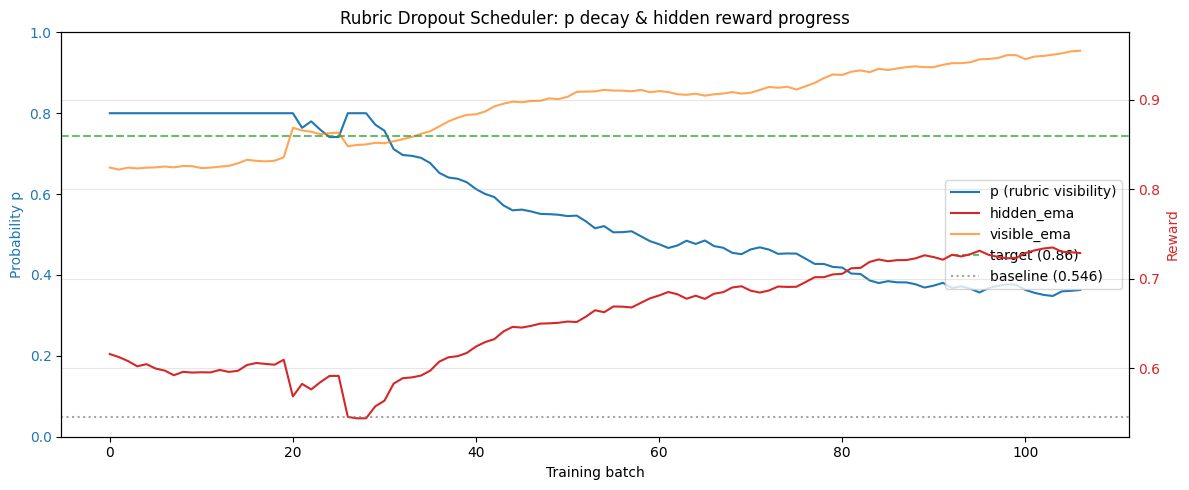

Baseline hidden: 0.5457
Final hidden_ema: 0.7289
Target: 0.86
Gap closed: 58.3%


In [2]:
# ================================================
# Cell 1: Rubric dropout scheduler — p, hidden_ema
# ================================================
# This is the most important plot for rubric dropout.
# p should decrease as hidden_ema rises toward the target.

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel("Training batch")
ax1.set_ylabel("Probability p", color="tab:blue")
ax1.plot(df_batch["batch_idx"], df_batch["rubric/p"], color="tab:blue", label="p (rubric visibility)")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.set_ylabel("Reward", color="tab:red")
ax2.plot(df_batch["batch_idx"], df_batch["rubric/reward_hidden_ema"], color="tab:red", label="hidden_ema")
ax2.plot(df_batch["batch_idx"], df_batch["rubric/reward_visible_ema"], color="tab:orange", alpha=0.7, label="visible_ema")

target = df_batch["rubric/target"].iloc[0] if "rubric/target" in df_batch.columns else 0.86
baseline = df_batch["rubric/baseline_hidden"].iloc[-1] if "rubric/baseline_hidden" in df_batch.columns else None
ax2.axhline(y=target, color="tab:green", linestyle="--", alpha=0.7, label=f"target ({target})")
if baseline and baseline > 0:
    ax2.axhline(y=baseline, color="tab:gray", linestyle=":", alpha=0.7, label=f"baseline ({baseline:.3f})")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.title("Rubric Dropout Scheduler: p decay & hidden reward progress")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Baseline hidden: {baseline:.4f}")
print(f"Final hidden_ema: {df_batch['rubric/reward_hidden_ema'].iloc[-1]:.4f}")
print(f"Target: {target}")
print(f"Gap closed: {(df_batch['rubric/reward_hidden_ema'].iloc[-1] - baseline) / (target - baseline) * 100:.1f}%")

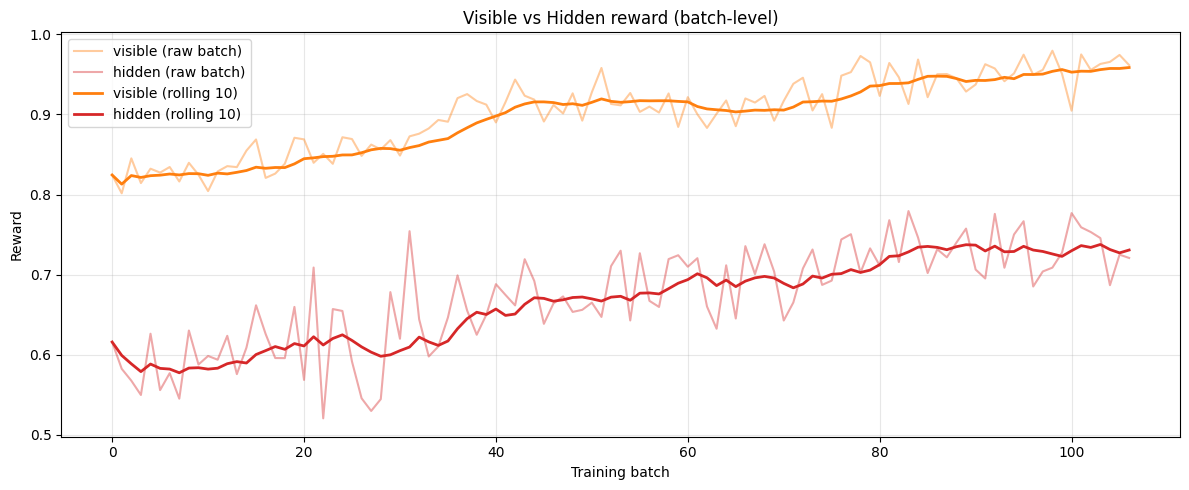

Visible-hidden gap: start=0.2351, end=0.2377


In [3]:
# ============================================
# Cell 2: Visible vs Hidden reward per batch
# ============================================
# Raw batch rewards split by rubric visibility.
# The gap between these should shrink as the model learns to infer criteria.

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_batch["batch_idx"], df_batch["rubric/reward_visible_batch"], alpha=0.4, color="tab:orange", label="visible (raw batch)")
ax.plot(df_batch["batch_idx"], df_batch["rubric/reward_hidden_batch"], alpha=0.4, color="tab:red", label="hidden (raw batch)")

# Rolling averages
window = 10
ax.plot(df_batch["batch_idx"], df_batch["rubric/reward_visible_batch"].rolling(window, min_periods=1).mean(),
        color="tab:orange", linewidth=2, label=f"visible (rolling {window})")
ax.plot(df_batch["batch_idx"], df_batch["rubric/reward_hidden_batch"].rolling(window, min_periods=1).mean(),
        color="tab:red", linewidth=2, label=f"hidden (rolling {window})")

ax.set_xlabel("Training batch")
ax.set_ylabel("Reward")
ax.set_title("Visible vs Hidden reward (batch-level)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gap over time
gap = df_batch["rubric/reward_visible_batch"] - df_batch["rubric/reward_hidden_batch"]
print(f"Visible-hidden gap: start={gap.iloc[:5].mean():.4f}, end={gap.iloc[-5:].mean():.4f}")

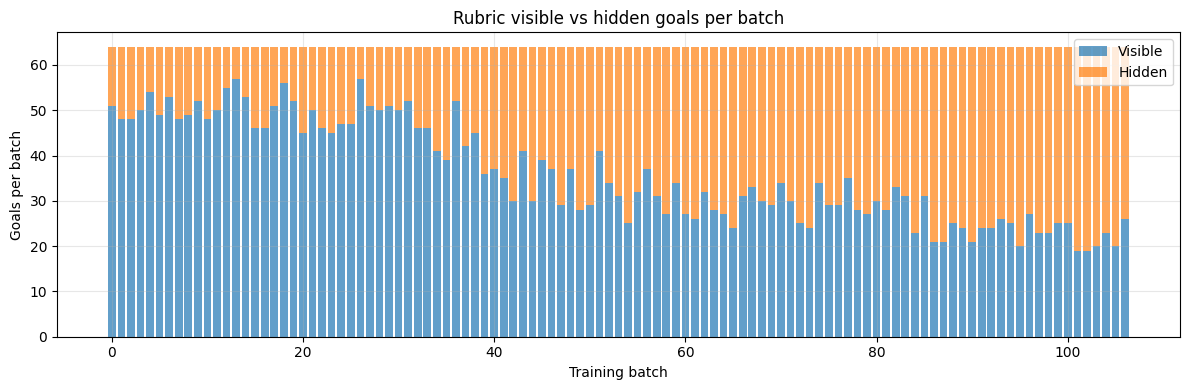

In [4]:
# ============================================
# Cell 3: Visible/Hidden sample counts
# ============================================
# Verify the scheduler is producing enough hidden samples.

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_batch["batch_idx"], df_batch["rubric/visible_count"], label="Visible", alpha=0.7)
ax.bar(df_batch["batch_idx"], df_batch["rubric/hidden_count"],
       bottom=df_batch["rubric/visible_count"], label="Hidden", alpha=0.7)
ax.set_xlabel("Training batch")
ax.set_ylabel("Goals per batch")
ax.set_title("Rubric visible vs hidden goals per batch")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

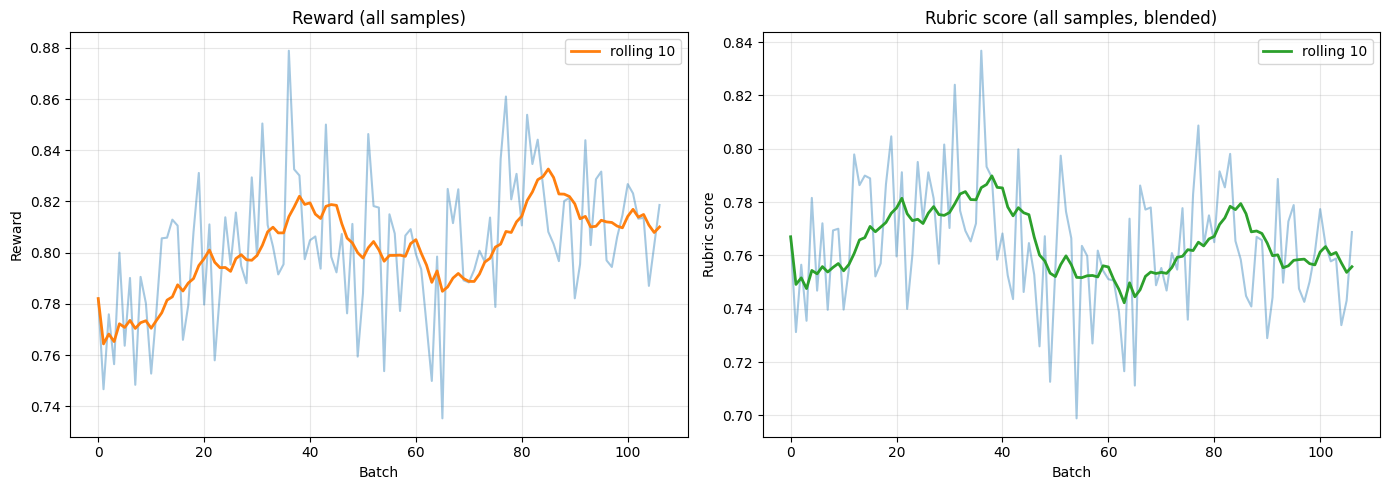

In [5]:
# ==========================================
# Cell 4: Overall reward and rubric trends
# ==========================================
# Note: the blended rubric_mean may appear flat because the
# visible/hidden mix shifts over training.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward
axes[0].plot(df_batch["batch_idx"], df_batch["reward/sample_mean_valid"], alpha=0.4)
axes[0].plot(df_batch["batch_idx"], df_batch["reward/sample_mean_valid"].rolling(10, min_periods=1).mean(),
             linewidth=2, label="rolling 10")
axes[0].set_title("Reward (all samples)")
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Reward")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rubric
axes[1].plot(df_batch["batch_idx"], df_batch["rubric/sample_mean_all"], alpha=0.4)
axes[1].plot(df_batch["batch_idx"], df_batch["rubric/sample_mean_all"].rolling(10, min_periods=1).mean(),
             linewidth=2, label="rolling 10", color="tab:green")
axes[1].set_title("Rubric score (all samples, blended)")
axes[1].set_xlabel("Batch")
axes[1].set_ylabel("Rubric score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

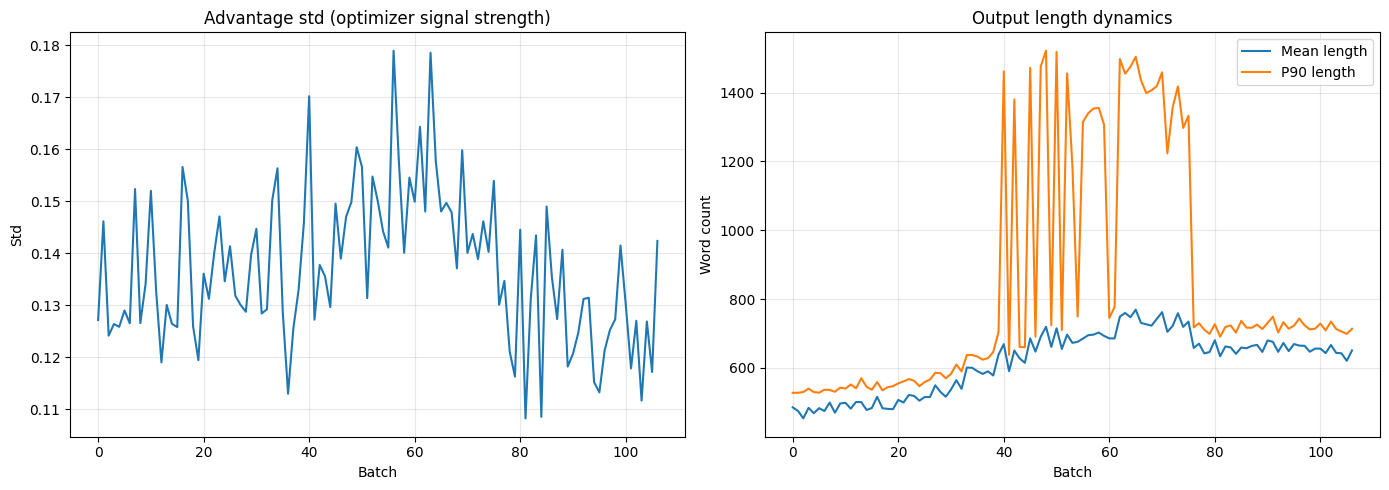

In [6]:
# ==========================================
# Cell 5: Advantage std & length dynamics
# ==========================================
# Watch for variance minimization: reward down + advantage_std down + length down.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_batch["batch_idx"], df_batch["advantage_std"])
axes[0].set_title("Advantage std (optimizer signal strength)")
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Std")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_batch["batch_idx"], df_batch["length_mean"], label="Mean length")
axes[1].plot(df_batch["batch_idx"], df_batch["length_p90"], label="P90 length")
axes[1].set_title("Output length dynamics")
axes[1].set_xlabel("Batch")
axes[1].set_ylabel("Word count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

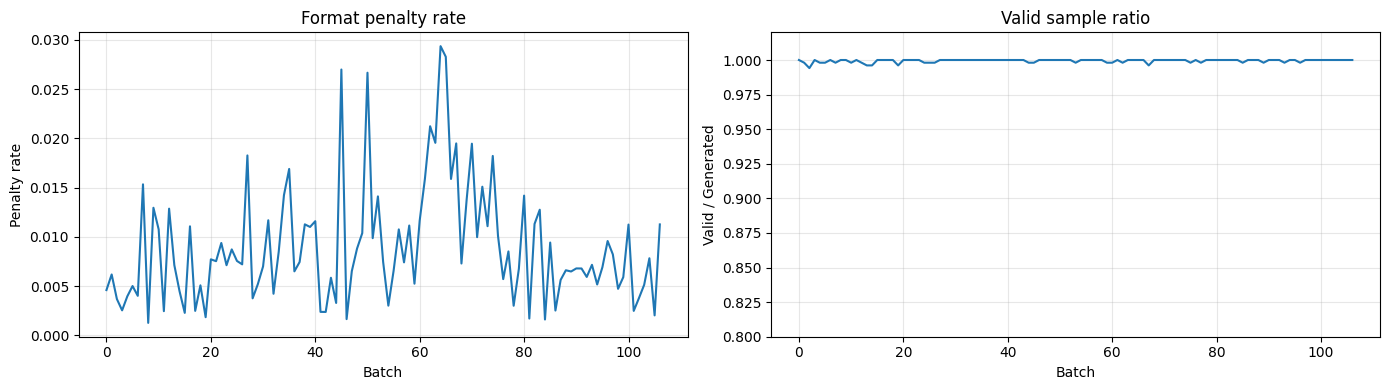

In [7]:
# ==========================================
# Cell 6: Format compliance & dropped samples
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_batch["batch_idx"], df_batch["format_rate"])
axes[0].set_title("Format penalty rate")
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Penalty rate")
axes[0].grid(True, alpha=0.3)

valid_ratio = df_batch["samples/valid"] / df_batch["samples/generated"]
axes[1].plot(df_batch["batch_idx"], valid_ratio)
axes[1].set_title("Valid sample ratio")
axes[1].set_xlabel("Batch")
axes[1].set_ylabel("Valid / Generated")
axes[1].set_ylim(0.8, 1.02)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

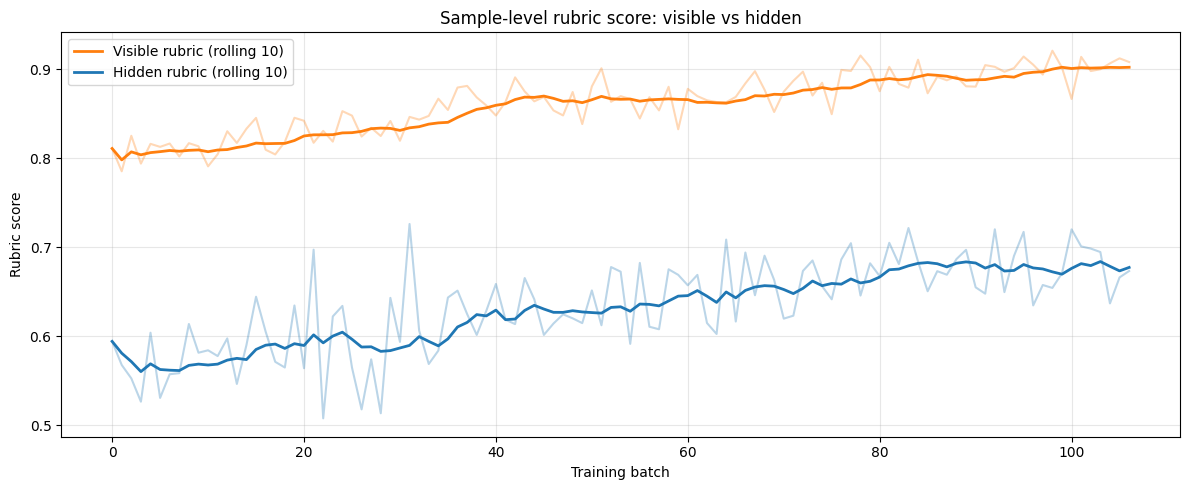

Visible samples: 30833, Hidden samples: 23919
Visible rubric mean: 0.8543
Hidden rubric mean: 0.6484


In [8]:
# ============================================
# Cell 7: Rubric score by visibility (hidden vs visible samples)
# ============================================
# Split sample-level rubric scores by whether the rubric was shown.

if "rubric_visible" in df_samples.columns:
    vis = df_samples[df_samples["rubric_visible"] == True]
    hid = df_samples[df_samples["rubric_visible"] == False]

    # Per-batch mean rubric for visible and hidden
    vis_by_batch = vis.groupby("batch_idx")["rubric_score"].mean()
    hid_by_batch = hid.groupby("batch_idx")["rubric_score"].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(vis_by_batch.index, vis_by_batch.values, alpha=0.3, color="tab:orange")
    ax.plot(vis_by_batch.rolling(10, min_periods=1).mean(), color="tab:orange", linewidth=2, label="Visible rubric (rolling 10)")
    ax.plot(hid_by_batch.index, hid_by_batch.values, alpha=0.3, color="tab:blue")
    ax.plot(hid_by_batch.rolling(10, min_periods=1).mean(), color="tab:blue", linewidth=2, label="Hidden rubric (rolling 10)")
    ax.set_xlabel("Training batch")
    ax.set_ylabel("Rubric score")
    ax.set_title("Sample-level rubric score: visible vs hidden")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Visible samples: {len(vis)}, Hidden samples: {len(hid)}")
    print(f"Visible rubric mean: {vis['rubric_score'].mean():.4f}")
    print(f"Hidden rubric mean: {hid['rubric_score'].mean():.4f}")
else:
    print("No rubric_visible column in sample logs")

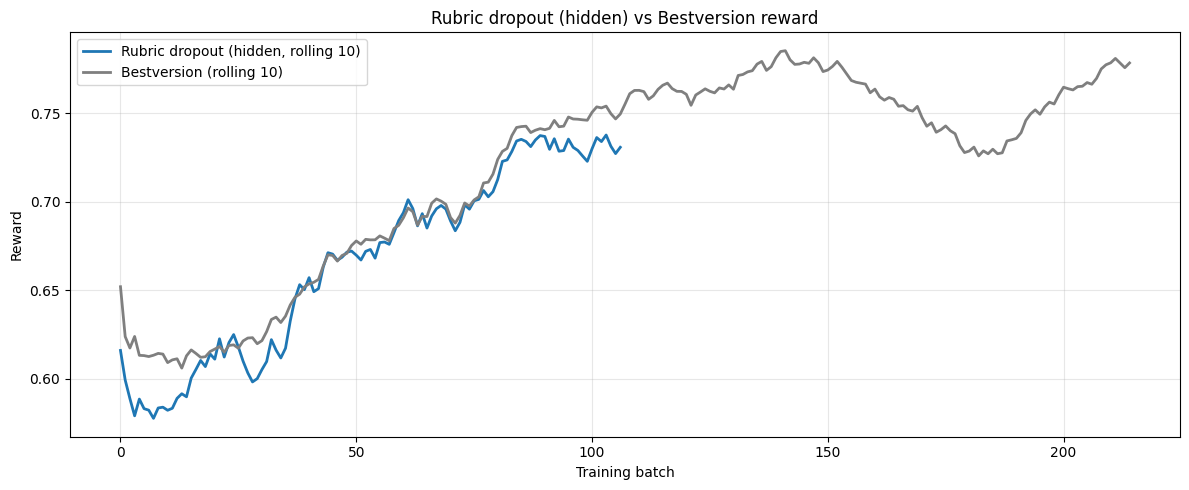

In [9]:
# ==========================================
# Cell 8: Comparison with bestversion baseline
# ==========================================
# Load bestversion metrics to compare reward trajectories.

bestver_path = "/home/silas/co-scientist-project/runs/2026/2/withA1,A2/2(ml)/train/batch_summary.jsonl"

if os.path.exists(bestver_path):
    df_bestver = pd.read_json(bestver_path, lines=True)

    fig, ax = plt.subplots(figsize=(12, 5))

    # Rubric dropout: hidden reward is the eval-relevant metric
    ax.plot(df_batch["batch_idx"], df_batch["rubric/reward_hidden_batch"].rolling(10, min_periods=1).mean(),
            color="tab:blue", linewidth=2, label="Rubric dropout (hidden, rolling 10)")

    # Bestversion: all samples are "hidden" (rubric never shown in prompt)
    ax.plot(df_bestver["batch_idx"], df_bestver["reward/sample_mean_valid"].rolling(10, min_periods=1).mean(),
            color="tab:gray", linewidth=2, label="Bestversion (rolling 10)")

    ax.set_xlabel("Training batch")
    ax.set_ylabel("Reward")
    ax.set_title("Rubric dropout (hidden) vs Bestversion reward")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Bestversion summary not found at {bestver_path}")

In [10]:
# ==========================================
# Cell 9: Automatic diagnosis
# ==========================================

def diagnose_rubric_dropout(df_batch, window=20):
    tail = df_batch.tail(window)
    head = df_batch.head(window)

    hidden_trend = tail["rubric/reward_hidden_ema"].iloc[-1] - tail["rubric/reward_hidden_ema"].iloc[0]
    p_trend = tail["rubric/p"].iloc[-1] - tail["rubric/p"].iloc[0]
    reward_trend = tail["reward/sample_mean_valid"].iloc[-1] - tail["reward/sample_mean_valid"].iloc[0]
    adv_trend = tail["advantage_std"].iloc[-1] - tail["advantage_std"].iloc[0]

    target = df_batch["rubric/target"].iloc[0] if "rubric/target" in df_batch.columns else 0.86
    baseline = df_batch["rubric/baseline_hidden"].iloc[-1] if "rubric/baseline_hidden" in df_batch.columns else None
    final_hidden = df_batch["rubric/reward_hidden_ema"].iloc[-1]

    print(f"=== Rubric Dropout Diagnosis (last {window} batches) ===")
    print(f"Hidden EMA trend:    {hidden_trend:+.4f}")
    print(f"p trend:             {p_trend:+.4f}")
    print(f"Reward trend:        {reward_trend:+.4f}")
    print(f"Advantage std trend: {adv_trend:+.4f}")
    print()
    if baseline and baseline > 0:
        gap_closed = (final_hidden - baseline) / (target - baseline) * 100
        print(f"Gap closed: {gap_closed:.1f}% ({baseline:.4f} -> {final_hidden:.4f}, target {target})")
    print()

    if hidden_trend > 0.01:
        print("Hidden reward still improving — training is productive")
    elif hidden_trend > -0.005:
        print("Hidden reward plateaued — consider stopping or adjusting")
    else:
        print("Hidden reward declining — possible degradation")

    if p_trend > 0.02:
        print("p is RISING — hidden performance may be regressing")
    elif p_trend < -0.02:
        print("p is falling — scheduler working correctly")
    else:
        print("p is stable")

diagnose_rubric_dropout(df_batch)

=== Rubric Dropout Diagnosis (last 20 batches) ===
Hidden EMA trend:    +0.0079
p trend:             -0.0188
Reward trend:        +0.0219
Advantage std trend: +0.0150

Gap closed: 58.3% (0.5457 -> 0.7289, target 0.86)

Hidden reward plateaued — consider stopping or adjusting
p is stable
